# Notebook 11b - Mammoth Domain-Mean RGB Decision Tree (SW Truth)

Train a decision tree model using GOES-18 RGB bands (`red`, `green`, `blue`) averaged over a Mammoth domain to predict cloud/no-cloud.

Truth labels are built from shortwave observations using a Long and Ackerman (2000)-style method.

Domain bounds used for RGB averaging:
- Latitude: `37.6` to `37.75` N
- Longitude: `-119.14` to `-118.86` W

In [6]:
import glob
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [7]:
# -------------------------
# User-configurable settings
# -------------------------
RGB_DIR = '/glade/u/home/cdalden/scratch/mammoth/goes18/rgb_composite'
MAMMOTH_CUES_NC = '/glade/u/home/cdalden/goes_work/analysis/CUES_1min_data_atmos_radiation_soiltemp_precip_2015to2025.nc'
MAMMOTH_SW_VAR = 'downwelling_shortwave_platform'
MAMMOTH_AIR_TEMP_VAR = 'air_temperature'

LAT_MIN, LAT_MAX = 37.6, 37.75
LON_MIN, LON_MAX = -119.14, -118.86

# Approximate domain-center location for solar geometry
SITE_LAT = 0.5 * (LAT_MIN + LAT_MAX)
SITE_LON = 0.5 * (LON_MIN + LON_MAX)
SITE_ALT_KM = 2.9

# Label thresholds (grid-search optimised for balanced accuracy)
CLOUDY_RATIO = 0.45
CLEAR_RATIO = 0.75
MIN_COS_SZA = 0.25
LOW_SW_CLOUDY = 80

# Time matching tolerance between GOES RGB samples and hourly SW labels
MERGE_TOLERANCE = '5min'

# Use all available data unless constrained
START_TIME = None
END_TIME = None

# Temperature-bin model settings
TEMP_BIN_WIDTH_C = 5.0
MIN_ROWS_PER_TEMP_BIN = 40
MIN_CLASS_COUNT_PER_TEMP_BIN = 10

# Output location
OUT_DIR = '/glade/u/home/cdalden/goes_work/analysis/output_11b_mammoth'
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

print('Output directory:', OUT_DIR)
print('Domain:', f'lat [{LAT_MIN}, {LAT_MAX}], lon [{LON_MIN}, {LON_MAX}]')
print('Mammoth CUES file:', MAMMOTH_CUES_NC)
print('SW variable:', MAMMOTH_SW_VAR)
print('Air temp variable:', MAMMOTH_AIR_TEMP_VAR)
print(f'Thresholds: CLOUDY_RATIO={CLOUDY_RATIO}, CLEAR_RATIO={CLEAR_RATIO}')
print(f'MERGE_TOLERANCE={MERGE_TOLERANCE}, TEMP_BIN_WIDTH_C={TEMP_BIN_WIDTH_C}')

Output directory: /glade/u/home/cdalden/goes_work/analysis/output_11b_mammoth
Domain: lat [37.6, 37.75], lon [-119.14, -118.86]
Mammoth CUES file: /glade/u/home/cdalden/goes_work/analysis/CUES_1min_data_atmos_radiation_soiltemp_precip_2015to2025.nc
SW variable: downwelling_shortwave_platform
Air temp variable: air_temperature
Thresholds: CLOUDY_RATIO=0.45, CLEAR_RATIO=0.75
MERGE_TOLERANCE=5min, TEMP_BIN_WIDTH_C=5.0


In [8]:
def _extract_mammoth_sw_from_cues_nc(nc_path, sw_var, air_temp_var):
    """Load Mammoth shortwave and air temperature from CUES NetCDF in analysis dir."""
    if not Path(nc_path).exists():
        raise FileNotFoundError(f'CUES file not found: {nc_path}')

    with xr.open_dataset(nc_path, decode_times=True) as ds:
        if sw_var not in ds.variables:
            raise KeyError(f'{sw_var} not found in {nc_path}')
        if air_temp_var not in ds.variables:
            raise KeyError(f'{air_temp_var} not found in {nc_path}')

        time_name = None
        for cand in ['time', 'datetime']:
            if cand in ds.coords or cand in ds.variables:
                time_name = cand
                break
        if time_name is None:
            raise KeyError('No time coordinate found (expected time or datetime).')

        sw = pd.DataFrame({
            'time': pd.to_datetime(ds[time_name].values, errors='coerce'),
            'obs_sw': pd.to_numeric(ds[sw_var].values, errors='coerce'),
            'air_temp_c': pd.to_numeric(ds[air_temp_var].values, errors='coerce'),
        })

    sw = sw.dropna(subset=['time', 'obs_sw']).sort_values('time').drop_duplicates('time').reset_index(drop=True)
    return sw

print('Using CUES file:', MAMMOTH_CUES_NC)
print('Using SW variable:', MAMMOTH_SW_VAR)
print('Using air temperature variable:', MAMMOTH_AIR_TEMP_VAR)

sw = _extract_mammoth_sw_from_cues_nc(
    MAMMOTH_CUES_NC,
    MAMMOTH_SW_VAR,
    MAMMOTH_AIR_TEMP_VAR,
)

if START_TIME is not None:
    sw = sw[sw['time'] >= pd.Timestamp(START_TIME)]
if END_TIME is not None:
    sw = sw[sw['time'] <= pd.Timestamp(END_TIME)]

sw = sw.sort_values('time').drop_duplicates('time').reset_index(drop=True)
print('SW rows in analysis window:', len(sw))
sw.head()

Using CUES file: /glade/u/home/cdalden/goes_work/analysis/CUES_1min_data_atmos_radiation_soiltemp_precip_2015to2025.nc
Using SW variable: downwelling_shortwave_platform
Using air temperature variable: air_temperature
SW rows in analysis window: 2862662


,time,obs_sw,air_temp_c
0,2015-01-01 00:00:00,0.8,-10.3
1,2015-01-01 00:01:00,0.9,-10.3
2,2015-01-01 00:02:00,0.9,-10.3
3,2015-01-01 00:03:00,1.0,-10.3
4,2015-01-01 00:04:00,1.3,-10.3


QC summary:
  Total rows: 2862662
  Physical bound fails: 56
  Nighttime bias fails: 1762782
  Spike fails: 77851
  Any QC fail: 1786294
  Remaining for labeling: 1076368


/glade/derecho/scratch/cdalden/tmp/ipykernel_43117/3675092516.py:91: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/glade/work/cdalden/conda-envs/goes_analysis/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


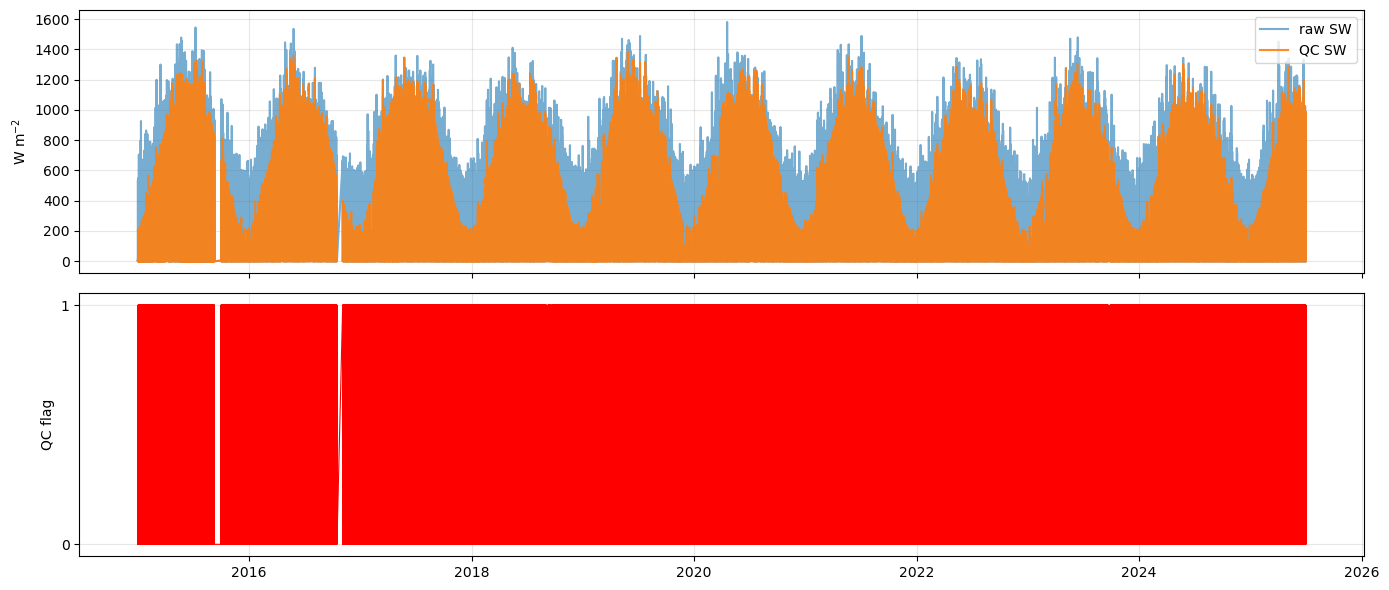

In [9]:
def calculate_solar_position(time, lat, lon):
    time = pd.to_datetime(time)

    # Handle both scalar timestamps and pandas datetime Series/Index.
    if isinstance(time, pd.Series):
        doy = time.dt.dayofyear
        hour = time.dt.hour + time.dt.minute / 60.0 + time.dt.second / 3600.0
    elif isinstance(time, pd.DatetimeIndex):
        doy = time.dayofyear
        hour = time.hour + time.minute / 60.0 + time.second / 3600.0
    else:
        t = pd.Timestamp(time)
        doy = t.dayofyear
        hour = t.hour + t.minute / 60.0 + t.second / 3600.0

    gamma = 2.0 * np.pi / 365.0 * (doy - 1 + (hour - 12.0) / 24.0)
    eqtime = 229.18 * (
        0.000075
        + 0.001868 * np.cos(gamma)
        - 0.032077 * np.sin(gamma)
        - 0.014615 * np.cos(2 * gamma)
        - 0.040849 * np.sin(2 * gamma)
    )
    decl = (
        0.006918
        - 0.399912 * np.cos(gamma)
        + 0.070257 * np.sin(gamma)
        - 0.006758 * np.cos(2 * gamma)
        + 0.000907 * np.sin(2 * gamma)
        - 0.002697 * np.cos(3 * gamma)
        + 0.00148 * np.sin(3 * gamma)
    )

    time_offset = eqtime + 4.0 * lon
    tst = hour * 60.0 + time_offset
    ha = np.deg2rad((tst / 4.0) - 180.0)

    lat_rad = np.deg2rad(lat)
    cos_sza = np.sin(lat_rad) * np.sin(decl) + np.cos(lat_rad) * np.cos(decl) * np.cos(ha)
    return np.clip(cos_sza, -1.0, 1.0)


# SW QC: keep only physically plausible and stable values for label generation.
sw['obs_sw_raw'] = sw['obs_sw'].astype(float)

# 1) Physical bounds
bad_physical = (sw['obs_sw_raw'] < -20) | (sw['obs_sw_raw'] > 1400)

# 2) Nighttime bias check using solar geometry
cos_sza_qc = calculate_solar_position(sw['time'], SITE_LAT, SITE_LON)
night_mask = np.asarray(cos_sza_qc) < 0.02
bad_night = night_mask & (np.abs(sw['obs_sw_raw'].to_numpy()) > 10)

# 3) Daytime spike filter (robust rolling MAD)
obs_med = sw['obs_sw_raw'].rolling(window=5, center=True, min_periods=3).median()
resid = sw['obs_sw_raw'] - obs_med
mad = resid.abs().rolling(window=9, center=True, min_periods=5).median()
# Protect against zero MAD; threshold ~6*MAD with small floor
spike_thresh = 6 * mad + 10
bad_spike = resid.abs() > spike_thresh

# Combine QC flags
sw['qc_bad_physical'] = bad_physical
sw['qc_bad_night'] = bad_night
sw['qc_bad_spike'] = bad_spike.fillna(False)
sw['qc_bad_any'] = sw[['qc_bad_physical', 'qc_bad_night', 'qc_bad_spike']].any(axis=1)

# QC'd SW used for cloud labeling
sw['obs_sw_qc'] = sw['obs_sw_raw'].where(~sw['qc_bad_any'])

print('QC summary:')
print(f"  Total rows: {len(sw)}")
print(f"  Physical bound fails: {int(sw['qc_bad_physical'].sum())}")
print(f"  Nighttime bias fails: {int(sw['qc_bad_night'].sum())}")
print(f"  Spike fails: {int(sw['qc_bad_spike'].sum())}")
print(f"  Any QC fail: {int(sw['qc_bad_any'].sum())}")
print(f"  Remaining for labeling: {int(sw['obs_sw_qc'].notna().sum())}")

fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ax[0].plot(sw['time'], sw['obs_sw_raw'], label='raw SW', alpha=0.6)
ax[0].plot(sw['time'], sw['obs_sw_qc'], label='QC SW', alpha=0.9)
ax[0].legend()
ax[0].set_ylabel('W m$^{-2}$')
ax[0].grid(alpha=0.3)

ax[1].plot(sw['time'], sw['qc_bad_any'].astype(int), color='r', linewidth=0.8)
ax[1].set_ylabel('QC flag')
ax[1].set_yticks([0, 1])
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Total SW timesteps: 2862662
Rows with QC SW: 1076368
Valid cloud labels: 607958
Ambiguous removed: 2254704
Cloud fraction (valid only): 0.740200803344968


/glade/derecho/scratch/cdalden/tmp/ipykernel_43117/2168690973.py:101: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/glade/work/cdalden/conda-envs/goes_analysis/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


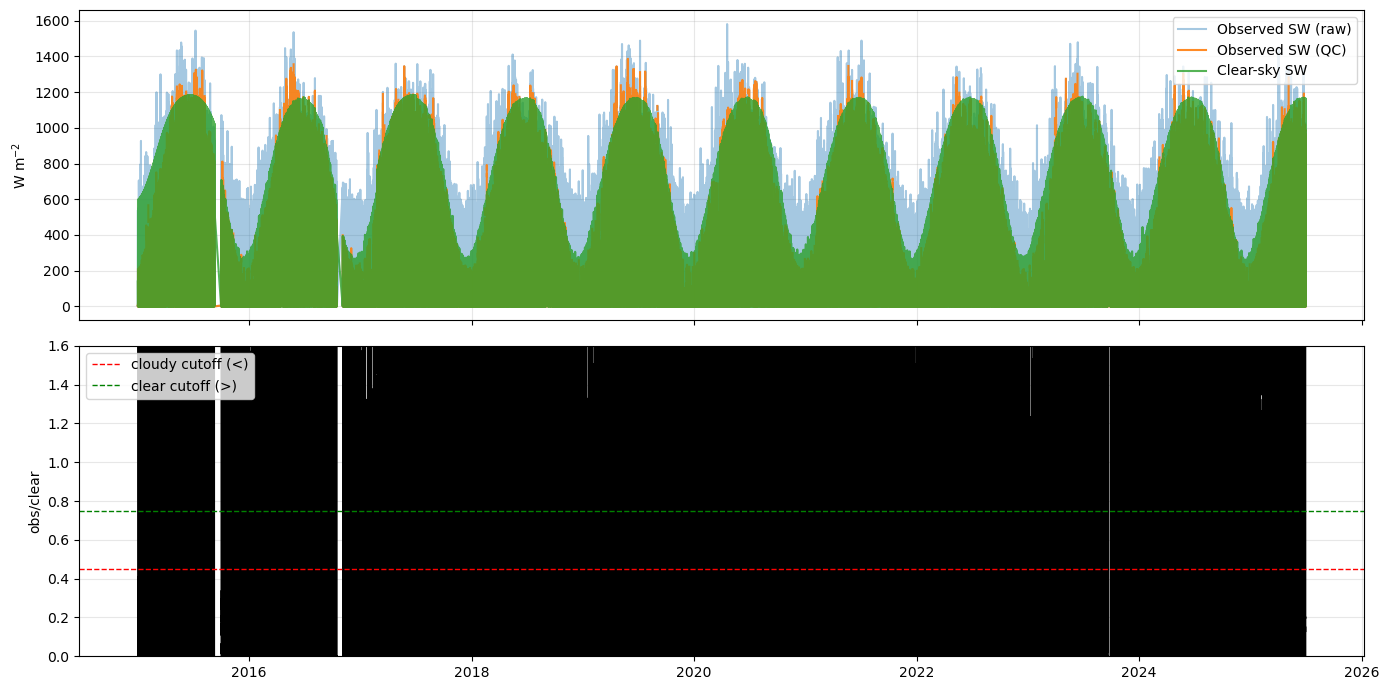

In [10]:
def calculate_solar_position(time, lat, lon):
    time = pd.to_datetime(time)

    # Handle both scalar timestamps and pandas datetime Series/Index.
    if isinstance(time, pd.Series):
        doy = time.dt.dayofyear
        hour = time.dt.hour + time.dt.minute / 60.0 + time.dt.second / 3600.0
    elif isinstance(time, pd.DatetimeIndex):
        doy = time.dayofyear
        hour = time.hour + time.minute / 60.0 + time.second / 3600.0
    else:
        ts = pd.Timestamp(time)
        doy = ts.dayofyear
        hour = ts.hour + ts.minute / 60.0 + ts.second / 3600.0

    declination = 23.45 * np.sin(np.radians(360 * (284 + doy) / 365))
    hour_angle = 15 * (hour - 12) + lon

    lat_rad = np.radians(lat)
    dec_rad = np.radians(declination)
    ha_rad = np.radians(hour_angle)

    cos_sza = (
        np.sin(lat_rad) * np.sin(dec_rad)
        + np.cos(lat_rad) * np.cos(dec_rad) * np.cos(ha_rad)
    )
    return np.maximum(cos_sza, 0)

def calculate_clear_sky_irradiance(cos_sza, altitude_km=2.9):
    S0 = 1361
    transmission = 0.78 + 0.04 * altitude_km
    return S0 * cos_sza * transmission

def long_ackerman_cloud_detection(
    obs_sw,
    clear_sky_sw,
    cos_sza,
    cloudy_ratio=0.85,
    clear_ratio=0.85,
    min_cos_sza=0.25,
    low_sw_cloudy=80,
):
    ratio = np.full_like(obs_sw, np.nan, dtype=float)
    valid_clear = clear_sky_sw > 0
    valid_obs = np.isfinite(obs_sw)
    valid_for_ratio = valid_clear & valid_obs
    ratio[valid_for_ratio] = obs_sw[valid_for_ratio] / clear_sky_sw[valid_for_ratio]

    cloud_binary = np.full_like(ratio, np.nan, dtype=float)
    valid_mask = (cos_sza >= min_cos_sza) & valid_for_ratio

    # Strict split for training labels:
    # cloudy: ratio < cloudy_ratio, clear: ratio > clear_ratio.
    # Middle values are left as NaN and excluded downstream.
    cloudy_mask = valid_mask & (ratio < cloudy_ratio)
    clear_mask = valid_mask & (ratio > clear_ratio)

    cloud_binary[cloudy_mask] = 1.0
    cloud_binary[clear_mask] = 0.0

    cloud_binary[(valid_mask) & (obs_sw < low_sw_cloudy)] = 1.0
    return cloud_binary

cos_sza = calculate_solar_position(sw['time'], SITE_LAT, SITE_LON)
clear_sky = calculate_clear_sky_irradiance(cos_sza, altitude_km=SITE_ALT_KM)

sw['clear_sky_sw'] = clear_sky
sw['sw_ratio'] = sw['obs_sw_qc'] / sw['clear_sky_sw']
sw['cloud_binary'] = long_ackerman_cloud_detection(
    obs_sw=sw['obs_sw_qc'].to_numpy(dtype=float),
    clear_sky_sw=sw['clear_sky_sw'].to_numpy(dtype=float),
    cos_sza=np.asarray(cos_sza, dtype=float),
    cloudy_ratio=CLOUDY_RATIO,
    clear_ratio=CLEAR_RATIO,
    min_cos_sza=MIN_COS_SZA,
    low_sw_cloudy=LOW_SW_CLOUDY,
)

valid = sw['cloud_binary'].notna()
print('Total SW timesteps:', len(sw))
print('Rows with QC SW:', int(sw['obs_sw_qc'].notna().sum()))
print('Valid cloud labels:', valid.sum())
print('Ambiguous removed:', (~valid).sum())
print('Cloud fraction (valid only):', float(sw.loc[valid, 'cloud_binary'].mean()))

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax[0].plot(sw['time'], sw['obs_sw_raw'], label='Observed SW (raw)', alpha=0.4)
ax[0].plot(sw['time'], sw['obs_sw_qc'], label='Observed SW (QC)', alpha=0.9)
ax[0].plot(sw['time'], sw['clear_sky_sw'], label='Clear-sky SW', alpha=0.8)
ax[0].set_ylabel('W m$^{-2}$')
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(sw['time'], sw['sw_ratio'], color='k', linewidth=0.8)
ax[1].axhline(CLOUDY_RATIO, color='r', linestyle='--', linewidth=1, label='cloudy cutoff (<)')
ax[1].axhline(CLEAR_RATIO, color='g', linestyle='--', linewidth=1, label='clear cutoff (>)')
ax[1].set_ylabel('obs/clear')
ax[1].set_ylim(0, 1.6)
ax[1].legend()
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
def goes18_xy_to_latlon(x_1d, y_1d):
    # GOES-18 fixed-grid projection constants
    lon_origin = -137.0
    perspective_point_height = 35786023.0
    semi_major_axis = 6378137.0
    semi_minor_axis = 6356752.31414

    H = perspective_point_height + semi_major_axis
    r_eq = semi_major_axis
    r_pol = semi_minor_axis

    x2d, y2d = np.meshgrid(x_1d, y_1d)
    lambda_0 = np.deg2rad(lon_origin)

    a = np.sin(x2d) ** 2 + np.cos(x2d) ** 2 * (
        np.cos(y2d) ** 2 + (r_eq ** 2 / r_pol ** 2) * np.sin(y2d) ** 2
    )
    b = -2.0 * H * np.cos(x2d) * np.cos(y2d)
    c = H ** 2 - r_eq ** 2

    rs = (-b - np.sqrt(b ** 2 - 4.0 * a * c)) / (2.0 * a)
    sx = rs * np.cos(x2d) * np.cos(y2d)
    sy = -rs * np.sin(x2d)
    sz = rs * np.cos(x2d) * np.sin(y2d)

    lat = np.rad2deg(np.arctan((r_eq ** 2 / r_pol ** 2) * (sz / np.sqrt((H - sx) ** 2 + sy ** 2))))
    lon = np.rad2deg(lambda_0 - np.arctan(sy / (H - sx)))
    return lat, lon

rgb_files = sorted(glob.glob(os.path.join(RGB_DIR, 'goes18_C02_C05_C13_rgb_mammoth_2024*.nc')))
if not rgb_files:
    raise FileNotFoundError(f'No Mammoth RGB files found in {RGB_DIR}')

print('RGB files found:', len(rgb_files))
print('First file:', rgb_files[0])
print('Last file :', rgb_files[-1])

ds0 = xr.open_dataset(rgb_files[0])
lat2d, lon2d = goes18_xy_to_latlon(ds0['x'].values, ds0['y'].values)
domain_mask = (
    (lat2d >= LAT_MIN) & (lat2d <= LAT_MAX) &
    (lon2d >= LON_MIN) & (lon2d <= LON_MAX)
)

print('lat range in sample file:', float(np.nanmin(lat2d)), float(np.nanmax(lat2d)))
print('lon range in sample file:', float(np.nanmin(lon2d)), float(np.nanmax(lon2d)))
print('Pixels in requested domain:', int(domain_mask.sum()))

if domain_mask.sum() == 0:
    raise ValueError('No pixels found in requested lat/lon bounds. Check domain or projection constants.')

RGB files found: 338
First file: /glade/u/home/cdalden/scratch/mammoth/goes18/rgb_composite/goes18_C02_C05_C13_rgb_mammoth_20240101.nc
Last file : /glade/u/home/cdalden/scratch/mammoth/goes18/rgb_composite/goes18_C02_C05_C13_rgb_mammoth_20241231.nc
lat range in sample file: 37.386680754739324 37.88441162334569
lon range in sample file: -119.45194870893303 -118.61504886931347
Pixels in requested domain: 1004


In [12]:
rgb_means = []

for i, f in enumerate(rgb_files, start=1):
    ds = xr.open_dataset(f)

    red_mean = ds['red'].where(domain_mask).mean(dim=('y', 'x'), skipna=True)
    green_mean = ds['green'].where(domain_mask).mean(dim=('y', 'x'), skipna=True)
    blue_mean = ds['blue'].where(domain_mask).mean(dim=('y', 'x'), skipna=True)

    rgb_means.append(
        pd.DataFrame({
            'time': pd.to_datetime(ds['t'].values),
            'red': red_mean.values,
            'green': green_mean.values,
            'blue': blue_mean.values,
        })
    )

    if i % 25 == 0 or i == len(rgb_files):
        print(f'Processed {i}/{len(rgb_files)} RGB files')

rgb_df = pd.concat(rgb_means, ignore_index=True)
rgb_df = rgb_df.dropna(subset=['red', 'green', 'blue']).sort_values('time').reset_index(drop=True)

if START_TIME is not None:
    rgb_df = rgb_df[rgb_df['time'] >= pd.Timestamp(START_TIME)]
if END_TIME is not None:
    rgb_df = rgb_df[rgb_df['time'] <= pd.Timestamp(END_TIME)]

print('RGB samples after domain-average and date filter:', len(rgb_df))
rgb_df.head()

Processed 25/338 RGB files
Processed 50/338 RGB files
Processed 75/338 RGB files
Processed 100/338 RGB files
Processed 125/338 RGB files
Processed 150/338 RGB files
Processed 175/338 RGB files
Processed 200/338 RGB files
Processed 225/338 RGB files
Processed 250/338 RGB files
Processed 275/338 RGB files
Processed 300/338 RGB files
Processed 325/338 RGB files
Processed 338/338 RGB files
RGB samples after domain-average and date filter: 96728


,time,red,green,blue
0,2024-01-01 00:02:30,0.791635,0.067513,0.035567
1,2024-01-01 00:07:30,0.782735,0.059743,0.029531
2,2024-01-01 00:12:30,0.782362,0.051836,0.023095
3,2024-01-01 00:17:30,0.788511,0.044688,0.018018
4,2024-01-01 00:22:30,0.798925,0.036532,0.011865


In [13]:
sw_valid = sw.dropna(subset=['cloud_binary']).copy()

# Ensure merge keys are same dtype for merge_asof.
rgb_merge = rgb_df.copy()
rgb_merge['time'] = pd.to_datetime(rgb_merge['time']).astype('datetime64[ns]')

sw_merge = sw_valid[['time', 'cloud_binary', 'obs_sw', 'clear_sky_sw', 'sw_ratio', 'air_temp_c']].copy()
sw_merge['time'] = pd.to_datetime(sw_merge['time']).astype('datetime64[ns]')

train_df = pd.merge_asof(
    rgb_merge.sort_values('time'),
    sw_merge.sort_values('time'),
    on='time',
    direction='nearest',
    tolerance=pd.Timedelta(MERGE_TOLERANCE),
)

train_df = train_df.dropna(subset=['red', 'green', 'blue', 'cloud_binary']).reset_index(drop=True)
train_df['cloud_binary'] = train_df['cloud_binary'].astype(int)

print('Training rows after time match:', len(train_df))
print('Rows with available air temp:', int(train_df['air_temp_c'].notna().sum()))
print('Class counts (0=clear, 1=cloudy):')
print(train_df['cloud_binary'].value_counts().sort_index())

train_df.head()

Training rows after time match: 10101
Rows with available air temp: 10101
Class counts (0=clear, 1=cloudy):
cloud_binary
0    3361
1    6740
Name: count, dtype: int64


,time,red,green,blue,cloud_binary,obs_sw,clear_sky_sw,sw_ratio,air_temp_c
0,2024-01-01 16:42:30,0.238546,0.047076,0.026497,1,0.0,305.964546,0.000000,-4.25
1,2024-01-01 16:47:30,0.233357,0.049803,0.029110,1,0.0,305.964546,0.000000,-4.25
2,2024-01-03 16:42:30,0.362835,0.113462,0.056613,1,14.4,305.856046,0.047081,-9.10
3,2024-01-03 16:47:30,0.366205,0.127921,0.068154,1,12.0,314.457559,0.038161,-9.10
4,2024-01-03 16:52:30,0.360933,0.129332,0.065917,1,6.8,328.562792,0.020696,-9.20


Temperature-bin model summary:
      temp_bin  temp_left_c  temp_right_c  n_rows  n_clear  n_cloudy  accuracy  clear_precision  clear_recall  clear_f1  cloudy_precision  cloudy_recall  cloudy_f1  macro_f1  status
[-20.0, -10.0)        -20.0         -10.0     117       11       106  1.000000         1.000000      1.000000  1.000000          1.000000       1.000000   1.000000  1.000000 trained
  [-10.0, 0.0)        -10.0           0.0    1129      108      1021  0.356890         0.129187      1.000000  0.228814          1.000000       0.289062   0.448485  0.338649 trained
   [0.0, 10.0)          0.0          10.0    2811      793      2018  0.873400         0.746606      0.833333  0.787589          0.931535       0.889109   0.909828  0.848709 trained
  [10.0, 20.0)         10.0          20.0    5237     1898      3339  0.923664         0.857143      0.947368  0.900000          0.968153       0.910180   0.938272  0.919136 trained
  [20.0, 30.0)         20.0          30.0     807      551 

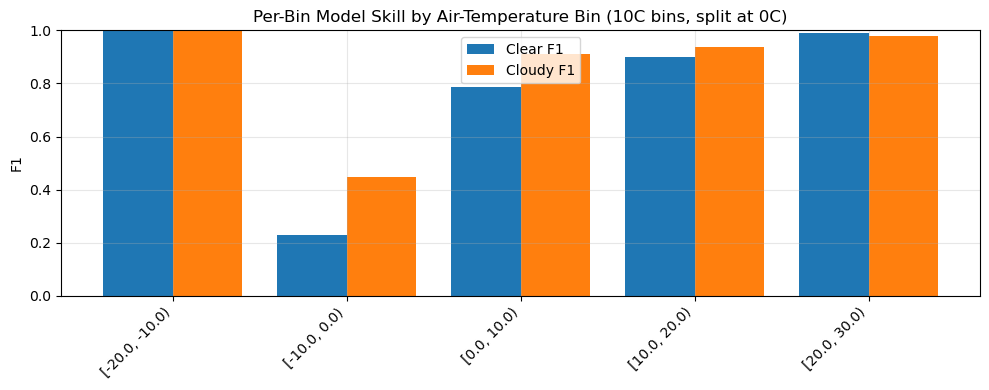

In [14]:
# Train separate decision-tree models by 10C hourly air-temperature bins (anchored at 0C).
bin_df = train_df.dropna(subset=['air_temp_c']).copy()
if bin_df.empty:
    raise ValueError('No rows with air_temp_c available for bin-specific training.')

bw = 10.0
# Force 0C to be an explicit split point: ..., -10, 0, 10, ...
tmin = np.floor(min(bin_df['air_temp_c'].min(), 0.0) / bw) * bw
tmax = np.ceil(max(bin_df['air_temp_c'].max(), 0.0) / bw) * bw
edges = np.arange(tmin, tmax + bw, bw)

bin_df['temp_bin'] = pd.cut(bin_df['air_temp_c'], bins=edges, right=False, include_lowest=True)

temp_bin_models = {}
temp_bin_metrics = []

for temp_bin, grp in bin_df.groupby('temp_bin', observed=False):
    if pd.isna(temp_bin):
        continue

    n_rows = len(grp)
    cls = grp['cloud_binary'].value_counts()
    n_clear = int(cls.get(0, 0))
    n_cloudy = int(cls.get(1, 0))

    if n_rows < MIN_ROWS_PER_TEMP_BIN or min(n_clear, n_cloudy) < MIN_CLASS_COUNT_PER_TEMP_BIN:
        temp_bin_metrics.append({
            'temp_bin': str(temp_bin),
            'temp_left_c': float(temp_bin.left),
            'temp_right_c': float(temp_bin.right),
            'n_rows': n_rows,
            'n_clear': n_clear,
            'n_cloudy': n_cloudy,
            'status': 'skipped_low_sample',
        })
        continue

    Xb = grp[['red', 'green', 'blue']]
    yb = grp['cloud_binary'].astype(int)

    X_tr, X_te, y_tr, y_te = train_test_split(
        Xb,
        yb,
        test_size=0.25,
        random_state=42,
        stratify=yb,
    )

    clf_bin = DecisionTreeClassifier(
        max_depth=3,
        min_samples_split=20,
        class_weight='balanced',
        random_state=42,
    )
    clf_bin.fit(X_tr, y_tr)

    y_hat = clf_bin.predict(X_te)
    rep = classification_report(
        y_te,
        y_hat,
        labels=[0, 1],
        target_names=['Clear', 'Cloudy'],
        output_dict=True,
        zero_division=0,
    )

    temp_bin_models[str(temp_bin)] = clf_bin
    temp_bin_metrics.append({
        'temp_bin': str(temp_bin),
        'temp_left_c': float(temp_bin.left),
        'temp_right_c': float(temp_bin.right),
        'n_rows': n_rows,
        'n_clear': n_clear,
        'n_cloudy': n_cloudy,
        'accuracy': rep['accuracy'],
        'clear_precision': rep['Clear']['precision'],
        'clear_recall': rep['Clear']['recall'],
        'clear_f1': rep['Clear']['f1-score'],
        'cloudy_precision': rep['Cloudy']['precision'],
        'cloudy_recall': rep['Cloudy']['recall'],
        'cloudy_f1': rep['Cloudy']['f1-score'],
        'macro_f1': rep['macro avg']['f1-score'],
        'status': 'trained',
    })

temp_bin_metrics_df = pd.DataFrame(temp_bin_metrics).sort_values('temp_left_c').reset_index(drop=True)
print('Temperature-bin model summary:')
print(temp_bin_metrics_df.to_string(index=False))

trained = temp_bin_metrics_df[temp_bin_metrics_df['status'] == 'trained']
if not trained.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(trained))
    ax.bar(x - 0.2, trained['clear_f1'], width=0.4, label='Clear F1')
    ax.bar(x + 0.2, trained['cloudy_f1'], width=0.4, label='Cloudy F1')
    ax.set_xticks(x)
    ax.set_xticklabels(trained['temp_bin'], rotation=45, ha='right')
    ax.set_ylabel('F1')
    ax.set_title('Per-Bin Model Skill by Air-Temperature Bin (10C bins, split at 0C)')
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No bins met training sample requirements.')

Tested 56 threshold combinations

Top 20 by clear_f1 (all candidates):
 cloudy_th  clear_th  gap  n_clear  n_cloudy  n_total  accuracy  bal_acc  clear_f1  cloudy_f1  macro_f1
      0.45      0.80 0.35     3160      6748     9908     0.887    0.883     0.831      0.915     0.873
      0.45      0.70 0.25     3557      6730    10287     0.878    0.876     0.831      0.904     0.867
      0.45      0.75 0.30     3361      6740    10101     0.882    0.878     0.830      0.910     0.870
      0.45      0.85 0.40     2987      6763     9750     0.888    0.884     0.827      0.917     0.872
      0.50      0.70 0.20     3537      7003    10540     0.882    0.871     0.826      0.910     0.868
      0.45      0.65 0.20     3773      6712    10485     0.873    0.865     0.826      0.900     0.863
      0.50      0.75 0.25     3344      7014    10358     0.881    0.873     0.822      0.911     0.866
      0.50      0.65 0.15     3752      6980    10732     0.870    0.864     0.819      0.898    

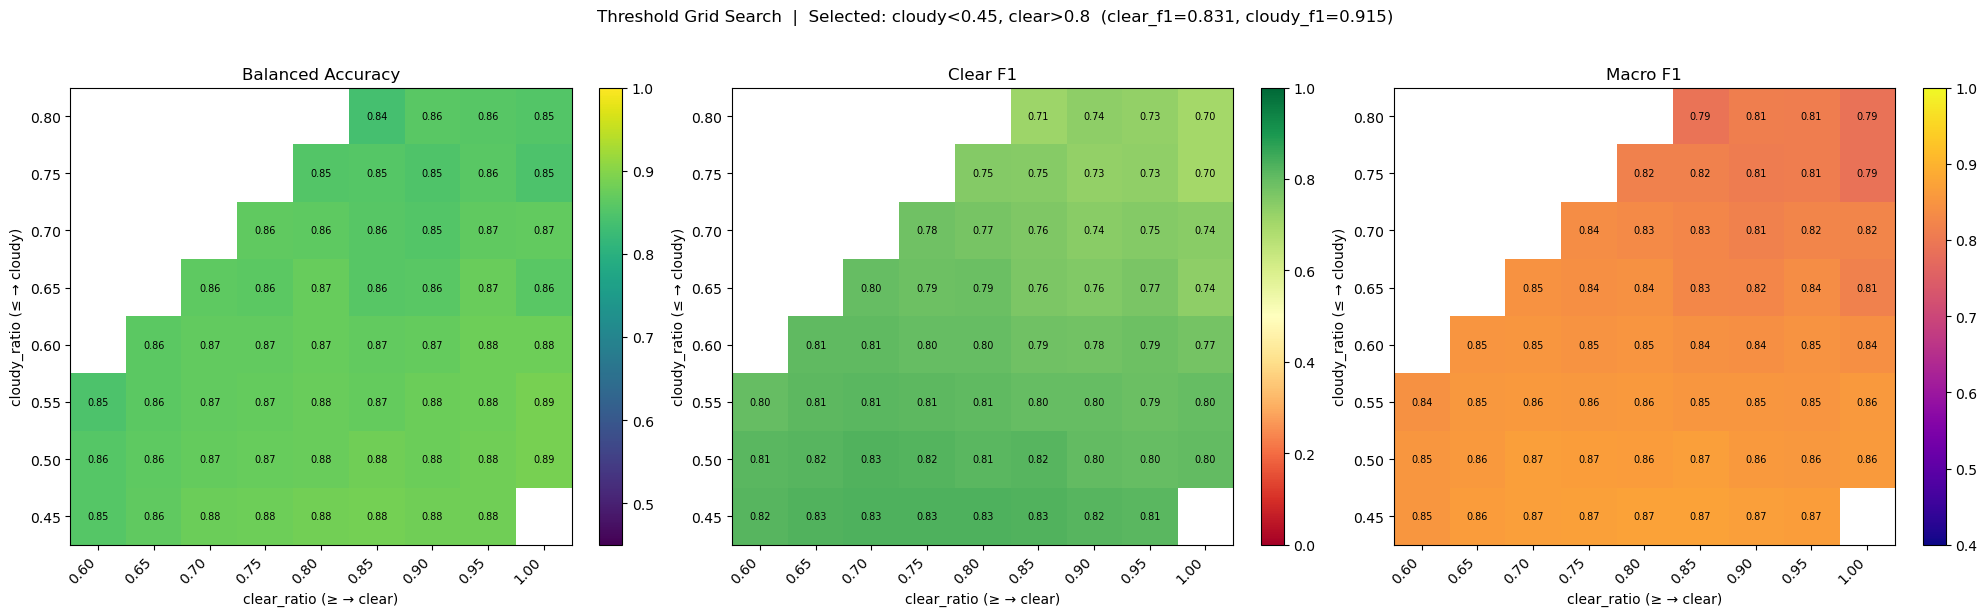

In [15]:
# --------------------------------------------------------------------------
# Threshold grid search: iterate cloudy_ratio / clear_ratio combinations
# Uses pre-computed sw (with obs_sw_qc, clear_sky_sw), cos_sza, and rgb_merge.
# --------------------------------------------------------------------------
from sklearn.metrics import balanced_accuracy_score, f1_score
import itertools

cloudy_candidates = [0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
clear_candidates  = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.00]

# Selection constraints to prioritize clear-sky skill while keeping cloudy skill strong.
MIN_CLOUDY_F1_FOR_SELECTION = 0.85
MIN_CLEAR_COUNT_FOR_SELECTION = 100

grid_results = []

for c_th, cl_th in itertools.product(cloudy_candidates, clear_candidates):
    if cl_th <= c_th:          # gap must exist
        continue
    if (cl_th - c_th) > 0.50:  # skip excessively wide gaps (discard too much data)
        continue

    # Re-label with this threshold pair
    labels = long_ackerman_cloud_detection(
        obs_sw=sw['obs_sw_qc'].to_numpy(dtype=float),
        clear_sky_sw=sw['clear_sky_sw'].to_numpy(dtype=float),
        cos_sza=np.asarray(cos_sza, dtype=float),
        cloudy_ratio=c_th,
        clear_ratio=cl_th,
        min_cos_sza=MIN_COS_SZA,
        low_sw_cloudy=LOW_SW_CLOUDY,
    )

    sw_trial = sw[['time']].copy()
    sw_trial['cloud_binary'] = labels
    sw_trial = sw_trial.dropna(subset=['cloud_binary'])

    counts = sw_trial['cloud_binary'].value_counts()
    if len(counts) < 2 or counts.min() < 15:
        continue

    sw_t = sw_trial.copy()
    sw_t['time'] = sw_t['time'].astype('datetime64[ns]')

    trial_df = pd.merge_asof(
        rgb_merge.sort_values('time'),
        sw_t.sort_values('time'),
        on='time',
        direction='nearest',
        tolerance=pd.Timedelta(MERGE_TOLERANCE),
    ).dropna(subset=['cloud_binary'])
    trial_df['cloud_binary'] = trial_df['cloud_binary'].astype(int)

    n_clear  = int((trial_df['cloud_binary'] == 0).sum())
    n_cloudy = int((trial_df['cloud_binary'] == 1).sum())
    if n_clear < 10 or n_cloudy < 10:
        continue

    Xt = trial_df[['red', 'green', 'blue']]
    yt = trial_df['cloud_binary']

    Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
        Xt, yt, test_size=0.25, random_state=42, stratify=yt
    )

    clf_t = DecisionTreeClassifier(
        max_depth=3, min_samples_split=20, class_weight='balanced', random_state=42
    )
    clf_t.fit(Xt_tr, yt_tr)
    yt_pred = clf_t.predict(Xt_te)

    grid_results.append({
        'cloudy_th': c_th,
        'clear_th':  cl_th,
        'gap':       round(cl_th - c_th, 2),
        'n_clear':   n_clear,
        'n_cloudy':  n_cloudy,
        'n_total':   n_clear + n_cloudy,
        'accuracy':  round(float((yt_pred == yt_te.to_numpy()).mean()), 3),
        'bal_acc':   round(float(balanced_accuracy_score(yt_te, yt_pred)), 3),
        'clear_f1':  round(float(f1_score(yt_te, yt_pred, pos_label=0, zero_division=0)), 3),
        'cloudy_f1': round(float(f1_score(yt_te, yt_pred, pos_label=1, zero_division=0)), 3),
        'macro_f1':  round(float(f1_score(yt_te, yt_pred, average='macro', zero_division=0)), 3),
    })

res_df = pd.DataFrame(grid_results)
if res_df.empty:
    raise ValueError('Threshold search produced no valid models.')

res_df = res_df.sort_values(['clear_f1', 'macro_f1', 'bal_acc'], ascending=False)
print(f'Tested {len(grid_results)} threshold combinations')

eligible = res_df[
    (res_df['cloudy_f1'] >= MIN_CLOUDY_F1_FOR_SELECTION)
    & (res_df['n_clear'] >= MIN_CLEAR_COUNT_FOR_SELECTION)
].copy()

if not eligible.empty:
    best = eligible.sort_values(['clear_f1', 'macro_f1', 'bal_acc'], ascending=False).iloc[0]
    selection_note = (
        f"best clear_f1 with cloudy_f1>={MIN_CLOUDY_F1_FOR_SELECTION} "
        f"and n_clear>={MIN_CLEAR_COUNT_FOR_SELECTION}"
    )
else:
    best = res_df.sort_values(['macro_f1', 'clear_f1', 'bal_acc'], ascending=False).iloc[0]
    selection_note = 'fallback to best macro_f1 (no row met clear/cloudy constraints)'

print('\nTop 20 by clear_f1 (all candidates):')
print(res_df.head(20).to_string(index=False))

print('\n★ Selected thresholds')
print(f'   CLOUDY_RATIO={best.cloudy_th}, CLEAR_RATIO={best.clear_th}')
print(f'   clear_f1={best.clear_f1}, cloudy_f1={best.cloudy_f1}, macro_f1={best.macro_f1}, bal_acc={best.bal_acc}')
print(f'   n_clear={int(best.n_clear)}, n_cloudy={int(best.n_cloudy)}')
print(f'   selection: {selection_note}')

# Apply selected thresholds and rebuild training labels/table used downstream.
CLOUDY_RATIO = float(best.cloudy_th)
CLEAR_RATIO = float(best.clear_th)

sw['cloud_binary'] = long_ackerman_cloud_detection(
    obs_sw=sw['obs_sw_qc'].to_numpy(dtype=float),
    clear_sky_sw=sw['clear_sky_sw'].to_numpy(dtype=float),
    cos_sza=np.asarray(cos_sza, dtype=float),
    cloudy_ratio=CLOUDY_RATIO,
    clear_ratio=CLEAR_RATIO,
    min_cos_sza=MIN_COS_SZA,
    low_sw_cloudy=LOW_SW_CLOUDY,
)

sw_valid = sw.dropna(subset=['cloud_binary']).copy()

sw_merge = sw_valid[['time', 'cloud_binary', 'obs_sw', 'clear_sky_sw', 'sw_ratio', 'air_temp_c']].copy()
sw_merge['time'] = pd.to_datetime(sw_merge['time']).astype('datetime64[ns]')

train_df = pd.merge_asof(
    rgb_merge.sort_values('time'),
    sw_merge.sort_values('time'),
    on='time',
    direction='nearest',
    tolerance=pd.Timedelta(MERGE_TOLERANCE),
)
train_df = train_df.dropna(subset=['red', 'green', 'blue', 'cloud_binary']).reset_index(drop=True)
train_df['cloud_binary'] = train_df['cloud_binary'].astype(int)

print(f'\nRebuilt train_df with selected thresholds: rows={len(train_df)}')
print(train_df['cloud_binary'].value_counts().sort_index())

# --- Heatmaps ---
pivot_bal  = res_df.pivot_table(values='bal_acc',  index='cloudy_th', columns='clear_th')
pivot_cf   = res_df.pivot_table(values='clear_f1', index='cloudy_th', columns='clear_th')
pivot_mf1  = res_df.pivot_table(values='macro_f1', index='cloudy_th', columns='clear_th')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

def annotated_heatmap(ax, data, title, cmap, vmin, vmax, fmt='.2f'):
    im = ax.imshow(data.values, origin='lower', aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels([f'{v:.2f}' for v in data.columns], rotation=45, ha='right')
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels([f'{v:.2f}' for v in data.index])
    ax.set_xlabel('clear_ratio (≥ → clear)')
    ax.set_ylabel('cloudy_ratio (≤ → cloudy)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
    for i in range(len(data.index)):
        for j in range(len(data.columns)):
            val = data.values[i, j]
            if not np.isnan(val):
                color = 'white' if val < (vmin + (vmax - vmin) * 0.55) else 'black'
                ax.text(j, i, format(val, fmt), ha='center', va='center', fontsize=7, color=color)
    return im

annotated_heatmap(axes[0], pivot_bal,  'Balanced Accuracy', 'viridis', 0.45, 1.0)
annotated_heatmap(axes[1], pivot_cf,   'Clear F1',          'RdYlGn',  0.0,  1.0)
annotated_heatmap(axes[2], pivot_mf1,  'Macro F1',          'plasma',  0.4,  1.0)

plt.suptitle(
    f'Threshold Grid Search  |  Selected: cloudy<{best.cloudy_th}, clear>{best.clear_th}  '
    f'(clear_f1={best.clear_f1}, cloudy_f1={best.cloudy_f1})',
    y=1.02,
)
plt.tight_layout()
plt.show()

In [16]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clear', 'Cloudy'])
fig, ax = plt.subplots(figsize=(6.5, 5.5))
disp.plot(
    ax=ax, 
    colorbar=True, 
    cmap='Blues',
    values_format='d',
    im_kw={'vmin': 0}
)
ax.set_title(
    f'Mammoth RGB (Gothic Thresholds) vs. SW-derived cloud binary\n'
    f'Accuracy={acc:.3f}  |  F1={f1_macro:.3f}',
    fontsize=11,
    fontweight='bold'
)
ax.set_xlabel('Predicted Label', fontsize=10)
ax.set_ylabel('True Label', fontsize=10)
plt.tight_layout()
plt.show()

print(f'\nOverall Metrics:')
print(f'  Accuracy: {acc:.4f}')
print(f'  Macro F1: {f1_macro:.4f}')
print(f'  Clear F1 (class 0): {f1_clear:.4f}')
print(f'  Cloudy F1 (class 1): {f1_cloudy:.4f}')

NameError: name 'y_test' is not defined

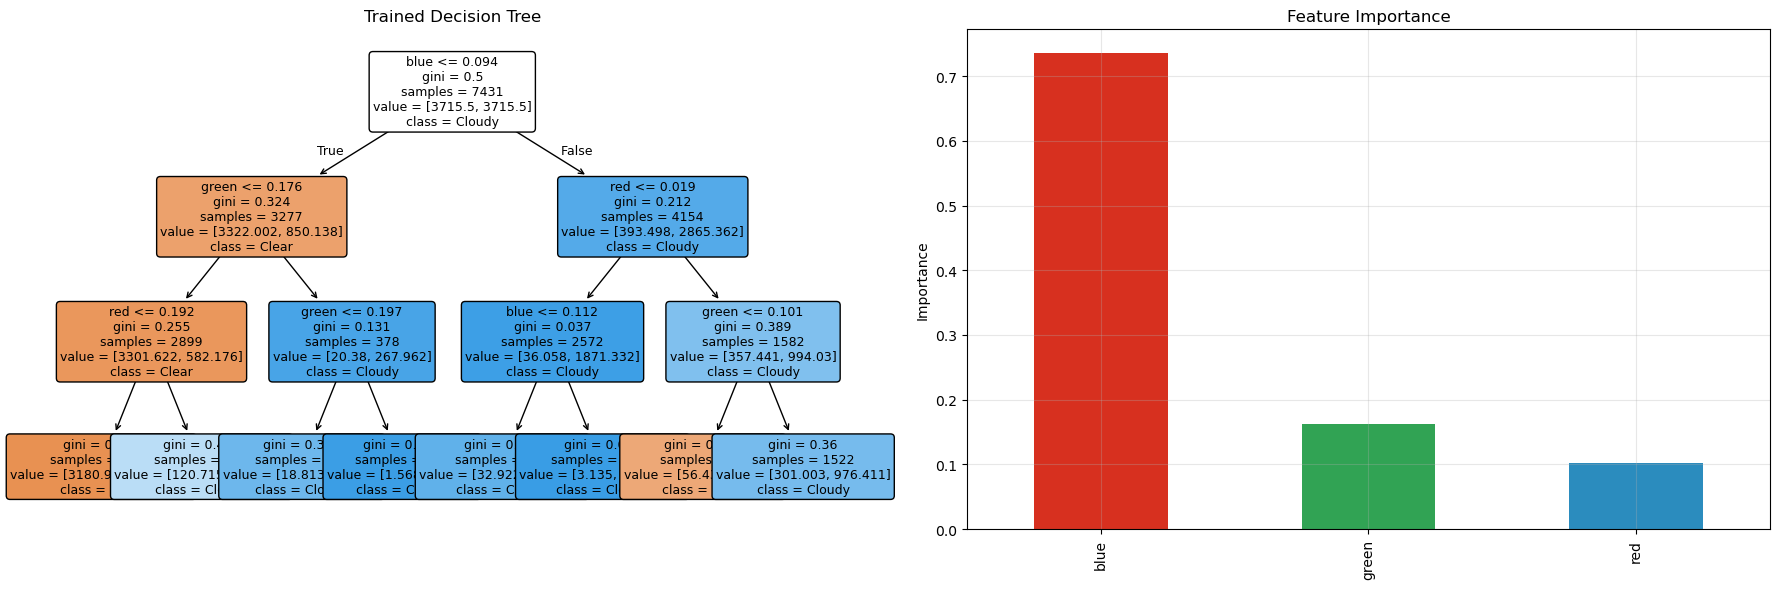

blue     0.735530
green    0.162028
red      0.102443
dtype: float64

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_tree(
    clf,
    feature_names=['red', 'green', 'blue'],
    class_names=['Clear', 'Cloudy'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=axes[0],
)
axes[0].set_title('Trained Decision Tree')

importance = pd.Series(clf.feature_importances_, index=['red', 'green', 'blue']).sort_values(ascending=False)
importance.plot(kind='bar', ax=axes[1], color=['#d7301f', '#31a354', '#2b8cbe'])
axes[1].set_title('Feature Importance')
axes[1].set_ylabel('Importance')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
importance

In [ ]:
rgb_out = os.path.join(OUT_DIR, 'mammoth_rgb_domain_mean_2024.csv')
train_out = os.path.join(OUT_DIR, 'mammoth_rgb_sw_training_table_2024.csv')
bin_metrics_out = os.path.join(OUT_DIR, 'mammoth_temp_bin_model_metrics.csv')

rgb_df.to_csv(rgb_out, index=False)
train_df.to_csv(train_out, index=False)
if 'temp_bin_metrics_df' in globals():
    temp_bin_metrics_df.to_csv(bin_metrics_out, index=False)

print('Saved domain-mean RGB table:', rgb_out)
print('Saved training table:', train_out)
if 'temp_bin_metrics_df' in globals():
    print('Saved temperature-bin model metrics:', bin_metrics_out)

Saved domain-mean RGB table: /glade/u/home/cdalden/goes_work/analysis/output_11b_mammoth/mammoth_rgb_domain_mean_2024.csv
Saved training table: /glade/u/home/cdalden/goes_work/analysis/output_11b_mammoth/mammoth_rgb_sw_training_table_2024.csv
Saved temperature-bin model metrics: /glade/u/home/cdalden/goes_work/analysis/output_11b_mammoth/mammoth_temp_bin_model_metrics.csv


## Notes
- This notebook computes GOES lat/lon from fixed-grid `x/y` and averages RGB values only inside your requested domain.
- SW timestamps are assumed local Pacific time and converted to UTC before matching GOES times.
- To use a different Mammoth SW source, update the CUES file/variable settings in the config cell and rerun from the top.

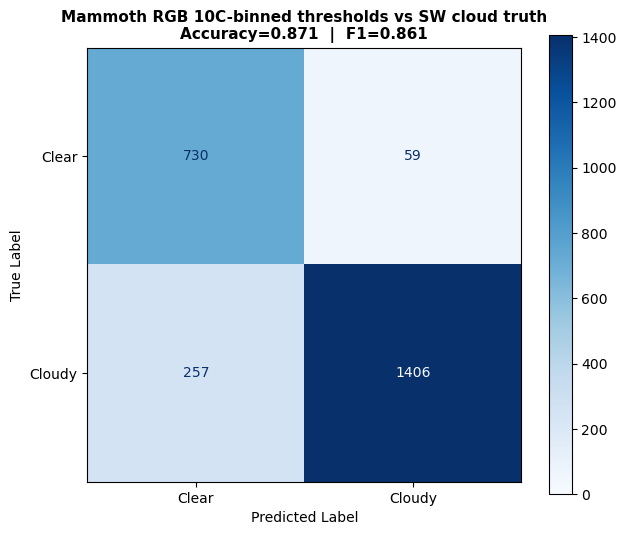

In [17]:
# 10C air-temperature-binned RGB thresholds (no global fallback, split at 0C) -> confusion matrix
nb = train_df.dropna(subset=['red', 'green', 'blue', 'air_temp_c', 'cloud_binary']).copy()
X = nb[['red', 'green', 'blue']]
y = nb['cloud_binary'].astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
t_tr = nb.loc[X_tr.index, 'air_temp_c']
t_te = nb.loc[X_te.index, 'air_temp_c']

bw = 10.0
# Force 0C to be an explicit split point: ..., -10, 0, 10, ...
tmin = np.floor(min(t_tr.min(), 0.0) / bw) * bw
tmax = np.ceil(max(t_tr.max(), 0.0) / bw) * bw
edges = np.arange(tmin, tmax + bw, bw)

models = {}
for b in pd.cut(t_tr, bins=edges, right=False, include_lowest=True).dropna().unique():
    idx = t_tr[(t_tr >= b.left) & (t_tr < b.right)].index
    yy = y_tr.loc[idx]
    if len(idx) >= 40 and yy.nunique() == 2 and yy.value_counts().min() >= 10:
        models[b] = DecisionTreeClassifier(max_depth=3, min_samples_split=20, class_weight='balanced', random_state=42).fit(X_tr.loc[idx], yy)

te_bins = pd.cut(t_te, bins=edges, right=False, include_lowest=True)
keep = te_bins.isin(models.keys())
if not keep.any():
    raise ValueError('No test rows fall in trained 10C bins; relax bin/sample thresholds.')

X_eval = X_te.loc[keep]
y_eval = y_te.loc[keep]
te_bins_eval = te_bins.loc[keep]
y_pred = np.array([int(models[b].predict(X_eval.loc[[i]])[0]) for i, b in te_bins_eval.items()])

acc = (y_pred == y_eval.to_numpy()).mean()
f1_macro = classification_report(y_eval, y_pred, labels=[0, 1], target_names=['Clear', 'Cloudy'], output_dict=True, zero_division=0)['macro avg']['f1-score']

cm = confusion_matrix(y_eval, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clear', 'Cloudy'])
fig, ax = plt.subplots(figsize=(6.5, 5.5))
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='d', im_kw={'vmin': 0})
ax.set_title(f'Mammoth RGB 10C-binned thresholds vs SW cloud truth\nAccuracy={acc:.3f}  |  F1={f1_macro:.3f}', fontsize=11, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=10)
ax.set_ylabel('True Label', fontsize=10)
plt.tight_layout()
plt.show()

## Parallel Analysis: LW-Derived Cloud Flags & RGB Comparison
Derive independent brightness-temperature-based cloud flags from GOES C13 (10.4 µm) and train RGB models to compare skill against SW-derived truth.


In [20]:
# =========================================================================
# LW-DERIVED CLOUD DETECTION: Using Downwelling Longwave from CUES
# =========================================================================
# Independently derive cloud flags from downwelling longwave radiation (CUES data).
# This provides a second independent cloud truth for evaluating GOES RGB thresholds.
# Similar method to SW: use a threshold-based clearness index approach

# Extract downwelling LW from CUES (alongside SW already loaded)
def _extract_mammoth_lw_from_cues_nc(nc_path, sw_var, lw_var, air_temp_var):
    """Load Mammoth LW and related variables from CUES NetCDF."""
    if not Path(nc_path).exists():
        raise FileNotFoundError(f'CUES file not found: {nc_path}')

    with xr.open_dataset(nc_path, decode_times=True) as ds:
        if lw_var not in ds.variables:
            raise KeyError(f'{lw_var} not found in {nc_path}')
        if air_temp_var not in ds.variables:
            raise KeyError(f'{air_temp_var} not found in {nc_path}')

        time_name = None
        for cand in ['time', 'datetime']:
            if cand in ds.coords or cand in ds.variables:
                time_name = cand
                break
        if time_name is None:
            raise KeyError('No time coordinate found.')

        lw_data = pd.DataFrame({
            'time': pd.to_datetime(ds[time_name].values, errors='coerce'),
            'obs_lw': pd.to_numeric(ds[lw_var].values, errors='coerce'),
            'air_temp': pd.to_numeric(ds[air_temp_var].values, errors='coerce'),
        })

    lw_data = lw_data.dropna(subset=['time', 'obs_lw', 'air_temp']).sort_values('time').drop_duplicates('time').reset_index(drop=True)
    return lw_data

# Load LW data from CUES
lw_var_name = None
with xr.open_dataset(MAMMOTH_CUES_NC, decode_times=True) as ds:
    for cand in ['downwelling_longwave_platform', 'downwelling_longwave', 'LW_down', 'lw_down']:
        if cand in ds.variables:
            lw_var_name = cand
            break
if lw_var_name is None:
    raise KeyError('No downwelling LW variable found in CUES file. Check available variables.')

lw = _extract_mammoth_lw_from_cues_nc(MAMMOTH_CUES_NC, MAMMOTH_SW_VAR, lw_var_name, MAMMOTH_AIR_TEMP_VAR)

# Simple cloud detection from LW: lower LW (clear) vs higher LW (cloudy)
# Clear sky has lower LW (less atmospheric greenhouse effect)
# Clouds increase LW (strong greenhouse effect)
lw_clear_th = np.percentile(lw['obs_lw'].dropna(), 25)   # Lower quartile = typically clear
lw_cloudy_th = np.percentile(lw['obs_lw'].dropna(), 75)  # Upper quartile = typically cloudy

lw_binary_vals = np.full(len(lw), np.nan, dtype=float)
lw_binary_vals[lw['obs_lw'] < lw_clear_th] = 0.0   # Clear
lw_binary_vals[lw['obs_lw'] > lw_cloudy_th] = 1.0  # Cloudy

lw['cloud_binary_lw'] = lw_binary_vals

# Merge LW cloud flags with RGB data
lw_valid = lw[lw['cloud_binary_lw'].notna()].copy()
lw_merge = lw_valid[['time', 'cloud_binary_lw', 'air_temp']].copy()
lw_merge['time'] = pd.to_datetime(lw_merge['time']).astype('datetime64[ns]')

train_df_lw = pd.merge_asof(
    rgb_merge.sort_values('time'),
    lw_merge.sort_values('time'),
    on='time',
    direction='nearest',
    tolerance=pd.Timedelta(MERGE_TOLERANCE),
)
train_df_lw = train_df_lw.dropna(subset=['red', 'green', 'blue', 'cloud_binary_lw', 'air_temp']).reset_index(drop=True)
train_df_lw['cloud_binary_lw'] = train_df_lw['cloud_binary_lw'].astype(int)
train_df_lw['air_temp_c'] = train_df_lw['air_temp']  # Use Kelvin values directly if already in C, or convert

print('Training rows with LW cloud binary:', len(train_df_lw))
print('Class counts (0=clear, 1=cloudy) from LW:')
print(train_df_lw['cloud_binary_lw'].value_counts().sort_index())
print(f'LW thresholds: clear < {lw_clear_th:.1f} W/m², cloudy > {lw_cloudy_th:.1f} W/m²')
print(f'LW variable used: {lw_var_name}')

Training rows with LW cloud binary: 51154
Class counts (0=clear, 1=cloudy) from LW:
cloud_binary_lw
0    24357
1    26797
Name: count, dtype: int64
LW thresholds: clear < 208.4 W/m², cloudy > 272.7 W/m²
LW variable used: downwelling_longwave_platform


In [21]:
# Train RGB decision tree on LW-derived cloud labels (same methodology as SW)
# Using 10C temperature-binned models

nb_lw = train_df_lw.dropna(subset=['red', 'green', 'blue', 'air_temp_c', 'cloud_binary_lw']).copy()
X_lw = nb_lw[['red', 'green', 'blue']]
y_lw = nb_lw['cloud_binary_lw'].astype(int)

X_tr_lw, X_te_lw, y_tr_lw, y_te_lw = train_test_split(
    X_lw, y_lw, test_size=0.25, random_state=42, stratify=y_lw
)
t_tr_lw = nb_lw.loc[X_tr_lw.index, 'air_temp_c']
t_te_lw = nb_lw.loc[X_te_lw.index, 'air_temp_c']

bw = 10.0
tmin_lw = np.floor(min(t_tr_lw.min(), 0.0) / bw) * bw
tmax_lw = np.ceil(max(t_tr_lw.max(), 0.0) / bw) * bw
edges_lw = np.arange(tmin_lw, tmax_lw + bw, bw)

models_lw = {}
for b in pd.cut(t_tr_lw, bins=edges_lw, right=False, include_lowest=True).dropna().unique():
    idx = t_tr_lw[(t_tr_lw >= b.left) & (t_tr_lw < b.right)].index
    yy = y_tr_lw.loc[idx]
    if len(idx) >= 40 and yy.nunique() == 2 and yy.value_counts().min() >= 10:
        models_lw[b] = DecisionTreeClassifier(
            max_depth=3, min_samples_split=20, class_weight='balanced', random_state=42
        ).fit(X_tr_lw.loc[idx], yy)

te_bins_lw = pd.cut(t_te_lw, bins=edges_lw, right=False, include_lowest=True)
keep_lw = te_bins_lw.isin(models_lw.keys())

if not keep_lw.any():
    print('Warning: No test rows fall in trained 10C LW bins; skipping LW evaluation.')
else:
    X_eval_lw = X_te_lw.loc[keep_lw]
    y_eval_lw = y_te_lw.loc[keep_lw]
    te_bins_eval_lw = te_bins_lw.loc[keep_lw]
    y_pred_lw = np.array([int(models_lw[b].predict(X_eval_lw.loc[[i]])[0]) for i, b in te_bins_eval_lw.items()])

    acc_lw = (y_pred_lw == y_eval_lw.to_numpy()).mean()
    f1_macro_lw = classification_report(
        y_eval_lw, y_pred_lw, labels=[0, 1], target_names=['Clear', 'Cloudy'],
        output_dict=True, zero_division=0
    )['macro avg']['f1-score']

    print(f'LW-derived RGB model skill:')
    print(f'  Accuracy: {acc_lw:.4f}')
    print(f'  Macro F1: {f1_macro_lw:.4f}')


LW-derived RGB model skill:
  Accuracy: 0.7711
  Macro F1: 0.7700


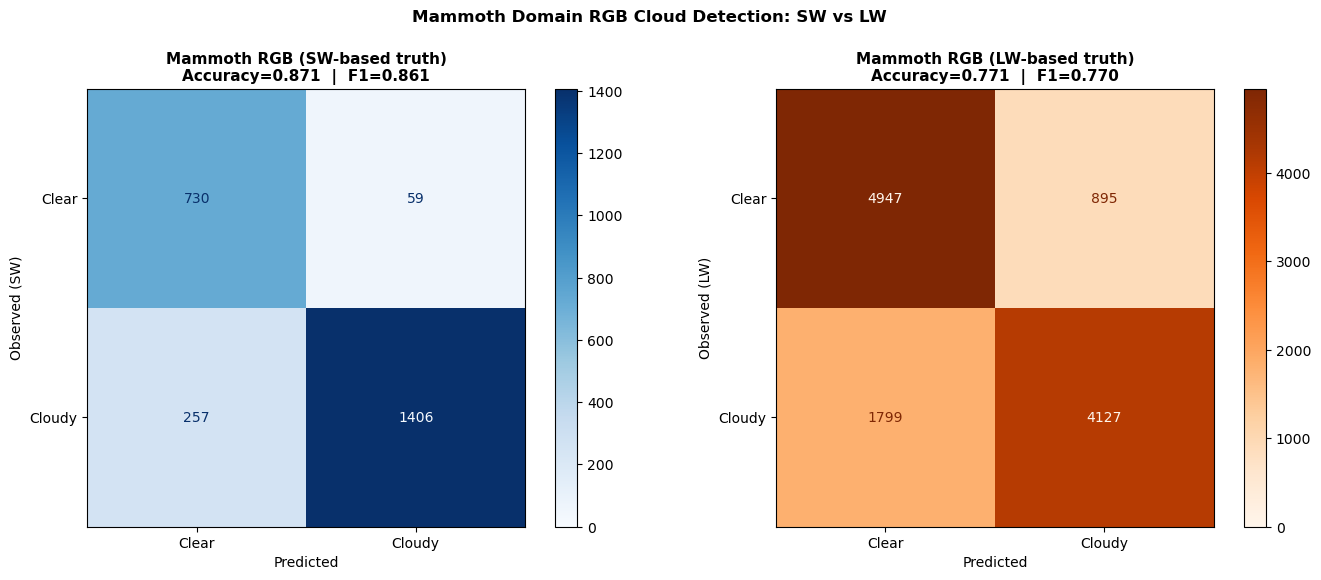


SUMMARY: SW vs LW RGB Model Performance (10C-binned)

SW-based truth (from downwelling shortwave):
  Accuracy: 0.8711  |  Macro F1: 0.8605
  N samples: 2452

LW-based truth (from downwelling longwave):
  Accuracy: 0.7711  |  Macro F1: 0.7700
  N samples: 11768
  LW thresholds: clear < 208.4 W/m², cloudy > 272.7 W/m²


In [23]:
# =========================================================================
# SIDE-BY-SIDE COMPARISON: SW vs LW RGB Model Skill (10C-binned)
# =========================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# SW-based RGB model (from earlier cell)
if 'y_eval' in locals() and len(y_eval) > 0:
    cm_sw = confusion_matrix(y_eval, y_pred)
    disp_sw = ConfusionMatrixDisplay(confusion_matrix=cm_sw, display_labels=['Clear', 'Cloudy'])
    disp_sw.plot(ax=axes[0], colorbar=True, cmap='Blues', values_format='d', im_kw={'vmin': 0})
    axes[0].set_title(
        f'Mammoth RGB (SW-based truth)\n'
        f'Accuracy={acc:.3f}  |  F1={f1_macro:.3f}',
        fontsize=11, fontweight='bold'
    )
    axes[0].set_xlabel('Predicted', fontsize=10)
    axes[0].set_ylabel('Observed (SW)', fontsize=10)
else:
    axes[0].text(0.5, 0.5, 'SW model not available', ha='center', va='center', transform=axes[0].transAxes)

# LW-based RGB model
if 'y_pred_lw' in locals() and len(y_eval_lw) > 0:
    cm_lw = confusion_matrix(y_eval_lw, y_pred_lw)
    disp_lw = ConfusionMatrixDisplay(confusion_matrix=cm_lw, display_labels=['Clear', 'Cloudy'])
    disp_lw.plot(ax=axes[1], colorbar=True, cmap='Oranges', values_format='d', im_kw={'vmin': 0})
    axes[1].set_title(
        f'Mammoth RGB (LW-based truth)\n'
        f'Accuracy={acc_lw:.3f}  |  F1={f1_macro_lw:.3f}',
        fontsize=11, fontweight='bold'
    )
    axes[1].set_xlabel('Predicted', fontsize=10)
    axes[1].set_ylabel('Observed (LW)', fontsize=10)
else:
    axes[1].text(0.5, 0.5, 'LW model not available', ha='center', va='center', transform=axes[1].transAxes)

plt.suptitle('Mammoth Domain RGB Cloud Detection: SW vs LW', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary comparison
print('\n' + '='*70)
print('SUMMARY: SW vs LW RGB Model Performance (10C-binned)')
print('='*70)
if 'y_eval' in locals() and len(y_eval) > 0:
    print(f'\nSW-based truth (from downwelling shortwave):')
    print(f'  Accuracy: {acc:.4f}  |  Macro F1: {f1_macro:.4f}')
    print(f'  N samples: {len(y_eval)}')
    
if 'y_pred_lw' in locals() and len(y_eval_lw) > 0:
    print(f'\nLW-based truth (from downwelling longwave):')
    print(f'  Accuracy: {acc_lw:.4f}  |  Macro F1: {f1_macro_lw:.4f}')
    print(f'  N samples: {len(y_eval_lw)}')
    print(f'  LW thresholds: clear < {lw_clear_th:.1f} W/m², cloudy > {lw_cloudy_th:.1f} W/m²')